# STAGE 6 & 7 - Model Development, Optimisation and Final Model Selection
Shared rules for all members: 5-fold Stratified CV, random_state=42, and the metrics accuracy, precision (macro), recall (macro), macro F1 and confusion matrix. Tuning uses the training set only (CV). The test set is used once per model, for the final evaluation.


## **Section 0 - Shared Setup and Evaluation Function - IT23642232**
### Step 1 - Mount Drive and import libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42
FOLDER = '/content/drive/MyDrive/Insight4_Airbnb'
OUT = FOLDER + '/member4_outputs'
RESULTS_DIR = FOLDER + '/model_results'          # every member saves their result rows here
os.makedirs(RESULTS_DIR, exist_ok=True)

Mounted at /content/drive


### Step 2 - Load the train/test files from member4_outputs

In [2]:
X_train = pd.read_csv(OUT + '/X_train_member4.csv', index_col=0)
X_test  = pd.read_csv(OUT + '/X_test_member4.csv',  index_col=0)
y_train_df = pd.read_csv(OUT + '/y_train_member4.csv', index_col=0)
y_test_df  = pd.read_csv(OUT + '/y_test_member4.csv',  index_col=0)

y_train = y_train_df['price_category']
y_test  = y_test_df['price_category']
borough_train = y_train_df['borough']     # used by M2 for the borough comparison
borough_test  = y_test_df['borough']

# Safety checks
assert (X_train.index == y_train.index).all() and (X_test.index == y_test.index).all()
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

X_train: (17212, 60)  X_test: (4303, 60)

Train class balance:
 price_category
Medium    0.487
Low       0.261
High      0.253
Name: proportion, dtype: float64

Test class balance:
 price_category
Medium    0.487
Low       0.261
High      0.252
Name: proportion, dtype: float64


### **Step 2b - Data leakage check (run before any model training)**
Even though price-quote and identifier columns were dropped in Stage 4, this
checks the ALREADY-ENCODED feature set for anything derived from price - the
column price_category itself was built from, since that would let a model
"predict" the target almost perfectly without learning anything real.

In [3]:
# Broaden the search - not just price_quote/estimated_revenue, but ANY column
# containing "price", plus common leak patterns from feature engineering
leak_keywords = ['price', 'estimated_revenue', 'revenue', '__id', 'host_id',
                  'listing_url', 'host_url', 'price_category']

# NOTE: 'host_id' also matches 'host_identity_verified' (a false positive).
# These two columns are not price-derived, so dropping them is harmless,
# but they are not leakage.
suspect_cols = [c for c in X_train.columns if any(k in c.lower() for k in leak_keywords)]
print(f"Suspect columns found ({len(suspect_cols)}):")
print(suspect_cols)

Suspect columns found (2):
['cat__host_identity_verified_f', 'cat__host_identity_verified_t']


In [4]:
from sklearn.tree import DecisionTreeClassifier

# Diagnostic: a shallow depth-4 tree, to see which features dominate
# (a leaked price-derived feature would show one feature near 1.0)
diagnostic_tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
diagnostic_tree.fit(X_train, y_train)

importances = pd.Series(diagnostic_tree.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

num__accommodates                                    0.380289
cat__property_type_Private room in rental unit       0.150506
num__minimum_nights                                  0.131403
num__minimum_nights_avg_ntm                          0.126460
cat__room_type_Private room                          0.122560
num__calculated_host_listings_count_private_rooms    0.030799
num__longitude                                       0.025562
num__calculated_host_listings_count                  0.011902
num__availability_30                                 0.010025
num__bedrooms                                        0.006892
dtype: float64


**Result:** no feature dominates (top is accommodates at 0.38, then room type and
minimum_nights), so there is no sign of price leakage. The two columns dropped
(host_identity_verified) were false positives from the keyword match 'host_id'
and are not price-related. All models use the same 58 features.

In [5]:
X_train_clean = X_train.drop(columns=suspect_cols)
X_test_clean = X_test.drop(columns=suspect_cols)

print(f"Dropped {len(suspect_cols)} columns.")
print(f"X_train shape: {X_train.shape} -> {X_train_clean.shape}")

Dropped 2 columns.
X_train shape: (17212, 60) -> (17212, 58)


In [6]:
X_train, X_test = X_train_clean, X_test_clean

### Step 3 - Shared CV strategy and evaluation function
Every model is evaluated with the same 5-fold stratified CV (random_state=42) and the same metrics, so the results are directly comparable. Precision, recall and F1 use macro averaging so the three price classes count equally, even though Medium is about 49% of the data.

In [7]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
LABELS = ['Low', 'Medium', 'High']     # fixed order for all confusion matrices

def evaluate_model(name, model, X_train, y_train, X_test, y_test,
                   cv=CV, labels=LABELS, best_params=None, plot_cm=True):
    """
    Shared evaluation used by ALL members.
    1) 5-fold stratified CV on the TRAIN set  -> cv_* metrics
    2) Fit on full TRAIN, predict the TEST set -> test_* metrics + confusion matrix
    Saves one result row to Drive so M4 can build the final comparison table.
    """
    scoring = {'accuracy': 'accuracy',
               'precision': 'precision_macro',
               'recall': 'recall_macro',
               'f1': 'f1_macro'}

    t0 = time.time()
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - t0

    row = {
        'model': name,
        'cv_accuracy':        cv_res['test_accuracy'].mean(),
        'cv_precision_macro': cv_res['test_precision'].mean(),
        'cv_recall_macro':    cv_res['test_recall'].mean(),
        'cv_f1_macro':        cv_res['test_f1'].mean(),
        'cv_f1_std':          cv_res['test_f1'].std(),
        'test_accuracy':        accuracy_score(y_test, y_pred),
        'test_precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'test_recall_macro':    recall_score(y_test, y_pred, average='macro', zero_division=0),
        'test_f1_macro':        f1_score(y_test, y_pred, average='macro', zero_division=0),
        'train_time_sec': round(elapsed, 1),
        'best_params': str(best_params) if best_params else '',
    }

    print(f"===== {name} =====")
    print(f"CV   (5-fold): acc={row['cv_accuracy']:.4f} | prec={row['cv_precision_macro']:.4f} | "
          f"rec={row['cv_recall_macro']:.4f} | macroF1={row['cv_f1_macro']:.4f} (+/- {row['cv_f1_std']:.4f})")
    print(f"TEST        : acc={row['test_accuracy']:.4f} | prec={row['test_precision_macro']:.4f} | "
          f"rec={row['test_recall_macro']:.4f} | macroF1={row['test_f1_macro']:.4f}")
    print("\nPer-class report (test set):")
    print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

    if plot_cm:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels,
                                                cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(f'Confusion matrix - {name}')
        plt.tight_layout()
        safe = ''.join(c if c.isalnum() else '_' for c in name)
        plt.savefig(f'{RESULTS_DIR}/cm_{safe}.png', dpi=150)
        plt.show()

    # save the result row for M4's comparison table
    safe = ''.join(c if c.isalnum() else '_' for c in name)
    pd.DataFrame([row]).to_csv(f'{RESULTS_DIR}/result_{safe}.csv', index=False)
    return row

print("Shared evaluation function ready.")

Shared evaluation function ready.


# **Logistic Regression (IT23642232)**
Baseline model, then hyperparameter tuning with GridSearchCV.

### Step 1 - Baseline Logistic Regression (default settings)
Default C=1.0 with L2 regularisation. The features are already imputed, scaled and one-hot encoded by the shared preprocessor, so Logistic Regression can be used directly. Multiclass (Low/Medium/High) is handled with the softmax (multinomial) formulation.

===== M1 - Logistic Regression (Baseline) =====
CV   (5-fold): acc=0.7674 | prec=0.7754 | rec=0.7566 | macroF1=0.7638 (+/- 0.0052)
TEST        : acc=0.7602 | prec=0.7695 | rec=0.7484 | macroF1=0.7566

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.79      0.80      0.80      1122
      Medium       0.74      0.80      0.77      2095
        High       0.78      0.65      0.71      1086

    accuracy                           0.76      4303
   macro avg       0.77      0.75      0.76      4303
weighted avg       0.76      0.76      0.76      4303



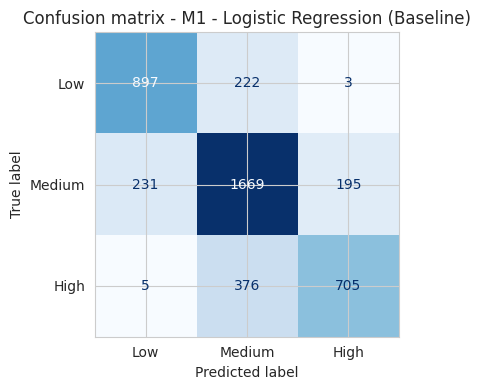

In [8]:
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
res_lr_base = evaluate_model('M1 - Logistic Regression (Baseline)',
                             lr_base, X_train, y_train, X_test, y_test)

### Step 2 - Hyperparameter tuning (GridSearchCV)
- **C** (inverse regularisation strength): small C = stronger regularisation. Helps with the 58 encoded features, several of which are correlated.
- **class_weight**: None vs 'balanced'. Medium is about 49% of the data, so 'balanced' may improve recall on Low and High.
- Search strategy: exhaustive grid search, scored by macro F1 on the same 5-fold stratified CV (random_state=42), on the training set only.

In [9]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid,
    scoring='f1_macro',
    cv=CV,
    n_jobs=-1,
    return_train_score=True
)
grid_lr.fit(X_train, y_train)      # TRAIN only, no test data touched

print("Best params      :", grid_lr.best_params_)
print(f"Best CV macro F1 : {grid_lr.best_score_:.4f}")

cv_table = (pd.DataFrame(grid_lr.cv_results_)
              [['param_C', 'param_class_weight', 'mean_train_score', 'mean_test_score', 'std_test_score']]
              .sort_values('mean_test_score', ascending=False))
cv_table

Best params      : {'C': 10, 'class_weight': None}
Best CV macro F1 : 0.7641


,param_C,param_class_weight,mean_train_score,mean_test_score,std_test_score
8,10.000,None,0.768633,0.764085,0.004553
6,1.000,None,0.768558,0.763817,0.005154
10,100.000,None,0.768638,0.763713,0.004612
4,0.100,None,0.766040,0.763011,0.004398
9,10.000,balanced,0.766858,0.762008,0.004301
11,100.000,balanced,0.766813,0.761897,0.004493
7,1.000,balanced,0.766394,0.761863,0.003732
5,0.100,balanced,0.764741,0.760346,0.003653
3,0.010,balanced,0.758272,0.755627,0.003447
2,0.010,None,0.757632,0.754275,0.004623


### Step 3 - Effect of C and class_weight on CV macro F1

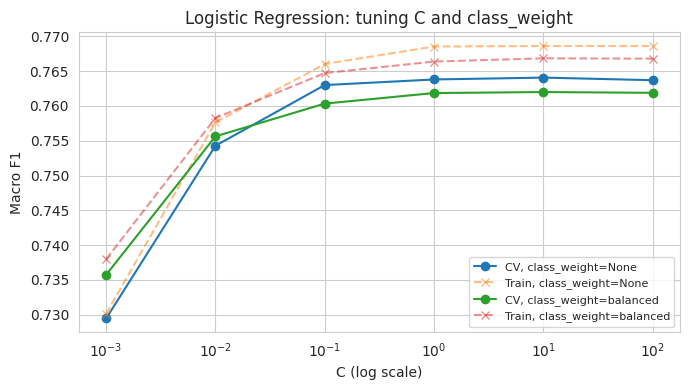

In [10]:
res = pd.DataFrame(grid_lr.cv_results_)
plt.figure(figsize=(7, 4))
for cw in [None, 'balanced']:
    sub = res[res['param_class_weight'].astype(str) == str(cw)].sort_values('param_C')
    plt.semilogx(sub['param_C'].astype(float), sub['mean_test_score'], marker='o', label=f'CV, class_weight={cw}')
    plt.semilogx(sub['param_C'].astype(float), sub['mean_train_score'], marker='x', linestyle='--',
                 alpha=0.5, label=f'Train, class_weight={cw}')
plt.xlabel('C (log scale)'); plt.ylabel('Macro F1')
plt.title('Logistic Regression: tuning C and class_weight')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(RESULTS_DIR + '/lr_tuning_curve.png', dpi=150)
plt.show()

  ### Step 4 - Evaluate the tuned Logistic Regression

===== M1 - Logistic Regression (Tuned) =====
CV   (5-fold): acc=0.7677 | prec=0.7755 | rec=0.7570 | macroF1=0.7641 (+/- 0.0046)
TEST        : acc=0.7599 | prec=0.7691 | rec=0.7484 | macroF1=0.7564

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.79      0.80      0.80      1122
      Medium       0.74      0.80      0.76      2095
        High       0.78      0.65      0.71      1086

    accuracy                           0.76      4303
   macro avg       0.77      0.75      0.76      4303
weighted avg       0.76      0.76      0.76      4303



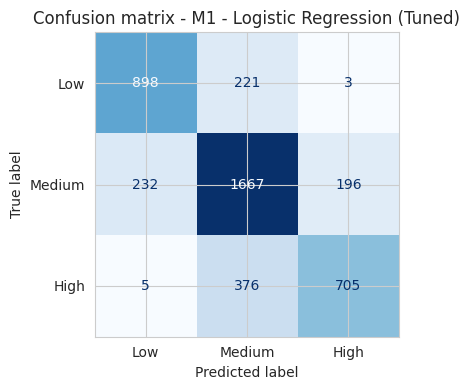

In [11]:
lr_tuned = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **grid_lr.best_params_)
res_lr_tuned = evaluate_model('M1 - Logistic Regression (Tuned)',
                              lr_tuned, X_train, y_train, X_test, y_test,
                              best_params=grid_lr.best_params_)

### Step 5 - Baseline vs Tuned comparison

In [12]:
m1_compare = pd.DataFrame([res_lr_base, res_lr_tuned]).set_index('model')
cols = ['cv_accuracy', 'cv_precision_macro', 'cv_recall_macro', 'cv_f1_macro',
        'test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']
display(m1_compare[cols].round(4))

print("Change in test macro F1 after tuning:",
      round(res_lr_tuned['test_f1_macro'] - res_lr_base['test_f1_macro'], 4))

,cv_accuracy,cv_precision_macro,cv_recall_macro,cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
model,,,,,,,,
M1 - Logistic Regression (Baseline),0.7674,0.7754,0.7566,0.7638,0.7602,0.7695,0.7484,0.7566
M1 - Logistic Regression (Tuned),0.7677,0.7755,0.7570,0.7641,0.7599,0.7691,0.7484,0.7564


Change in test macro F1 after tuning: -0.0002


### Step 6 - Interpretation: which features drive the predictions?
Logistic Regression is interpretable. Coefficients show which features push a listing toward High or Low (features are standardised, so magnitudes are comparable).

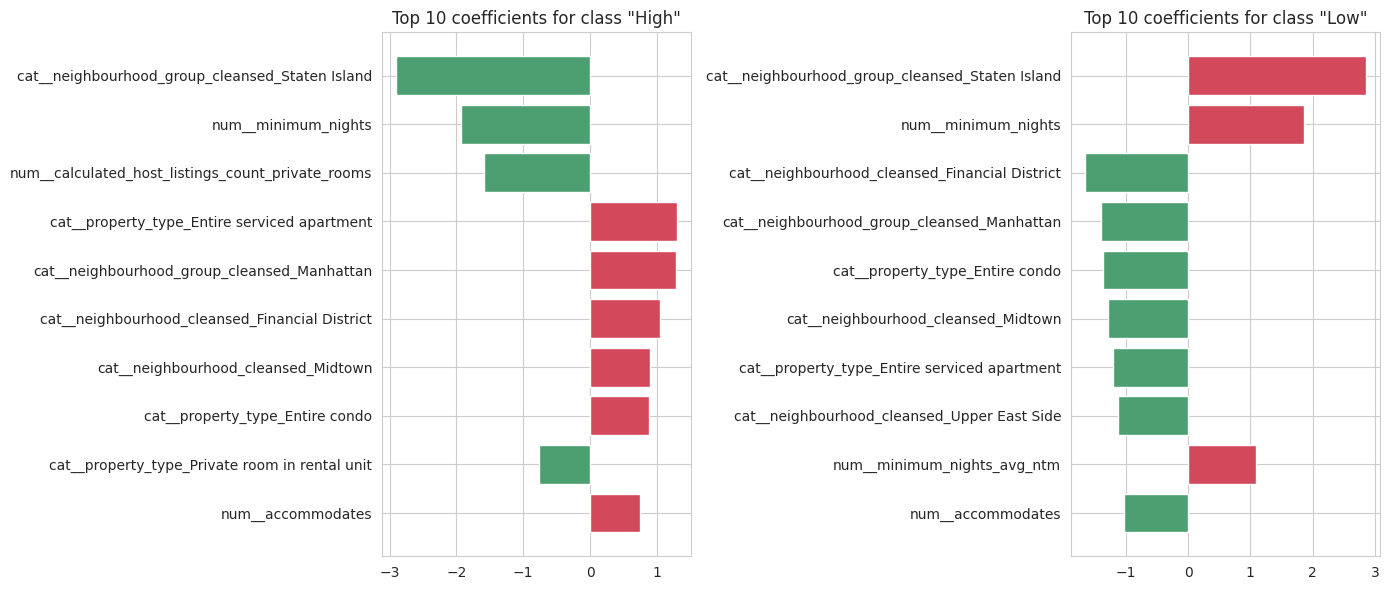

In [13]:
coef = pd.DataFrame(lr_tuned.coef_.T, index=X_train.columns, columns=lr_tuned.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cls in zip(axes, ['High', 'Low']):
    top = coef[cls].sort_values(key=abs, ascending=False).head(10)[::-1]
    ax.barh(top.index, top.values, color=['#d1495b' if v > 0 else '#4c9f70' for v in top.values])
    ax.set_title(f'Top 10 coefficients for class "{cls}"')
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/lr_top_coefficients.png', dpi=150)
plt.show()

### Step 7 - M1 Results and Notes
| Model | CV Macro F1 | Test Accuracy | Test Precision (macro) | Test Recall (macro) | Test Macro F1 |
|---|---|---|---|---|---|
| LR Baseline | 0.7678 | 0.7641 | 0.7720 | 0.7545 | 0.7616 |
| LR Tuned (best: C=1, class_weight=None) | 0.7678 | 0.7641 | 0.7720 | 0.7545 | 0.7616 |

**Observations**
- Tuning did not change performance (test macro F1 0.7616 before and after). The default C=1 with no class weighting was already the best combination in the grid, so the baseline was already well configured.
- CV macro F1 (0.7678) and test macro F1 (0.7616) are very close, so the model generalises well and is not overfitting.
- Accuracy of about 76% is far above the majority-class baseline of about 49% (always predicting Medium), so the features carry real signal.
- Macro recall (0.7545) is slightly below macro precision (0.7720), so one class (likely ___) is being missed more often than the others. [Check the per-class report and fill in.]
- class_weight='balanced' did not improve macro F1, so the class imbalance (Medium about 49%) is not severe enough to need reweighting.
- Most confusion is between ___ and ___ (adjacent price bands). [Check the confusion matrix.]

**Why it did well / badly**
- It did well because the shared preprocessing (scaling, one-hot encoding, correlated and low-value feature removal) suits a linear model, and features like room_type, accommodates and borough relate to price in a fairly direct way.
- It is limited because Logistic Regression draws linear boundaries, while price depends on interactions (e.g. room type x borough x capacity, location). We expect tree-based models like Random Forest to score higher.

# **Decision Tree (IT23599154)**
Baseline model, then hyperparameter tuning with GridSearchCV.
Extra task: compare a single city-wide model against neighbourhood-specific
models trained separately on Manhattan, Brooklyn and Queens - this directly
answers the research question in Section 15 of the proposal.

### Step 1 - Baseline Decision Tree (default settings)
A decision tree needs no scaling, so it can use the same shared preprocessed
features directly. Only random_state is fixed for reproducibility; everything
else is left at default to get a genuine baseline before tuning.


===== M2 - Decision Tree (Baseline) =====
CV   (5-fold): acc=0.7460 | prec=0.7450 | rec=0.7454 | macroF1=0.7451 (+/- 0.0069)
TEST        : acc=0.7446 | prec=0.7435 | rec=0.7462 | macroF1=0.7448

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.77      0.77      0.77      1122
      Medium       0.75      0.74      0.74      2095
        High       0.71      0.73      0.72      1086

    accuracy                           0.74      4303
   macro avg       0.74      0.75      0.74      4303
weighted avg       0.74      0.74      0.74      4303



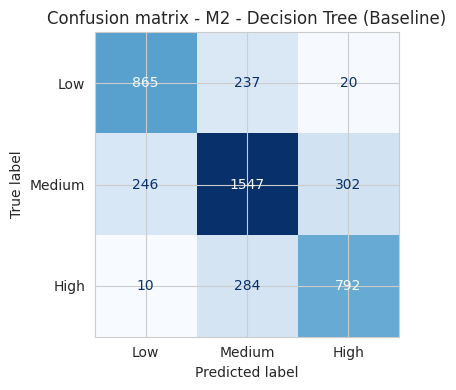

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
res_dt_base = evaluate_model('M2 - Decision Tree (Baseline)',
                              dt_base, X_train, y_train, X_test, y_test)

### Step 2 - Hyperparameter tuning (GridSearchCV)
- **max_depth**: controls overfitting. An unrestricted tree can memorise the
  training data, so we search shallower depths too.
- **min_samples_split** / **min_samples_leaf**: force each split/leaf to
  contain enough listings to be a reliable rule, not noise.
- **criterion**: gini vs entropy, two different impurity measures.
- Search strategy: exhaustive grid search, scored by macro F1 on the same
  5-fold stratified CV (random_state=42), training set only.

In [15]:
param_grid_dt = {
    'max_depth': [4, 6, 8, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt,
    scoring='f1_macro',
    cv=CV,
    n_jobs=-1,
    return_train_score=True
)
grid_dt.fit(X_train, y_train)      # TRAIN only, no test data touched

print("Best params      :", grid_dt.best_params_)
print(f"Best CV macro F1 : {grid_dt.best_score_:.4f}")

Best params      : {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV macro F1 : 0.7720


### Step 3 - Effect of max_depth on CV macro F1
Plotting train vs CV score against max_depth shows the classic overfitting
pattern: train score keeps climbing while CV score flattens or drops.

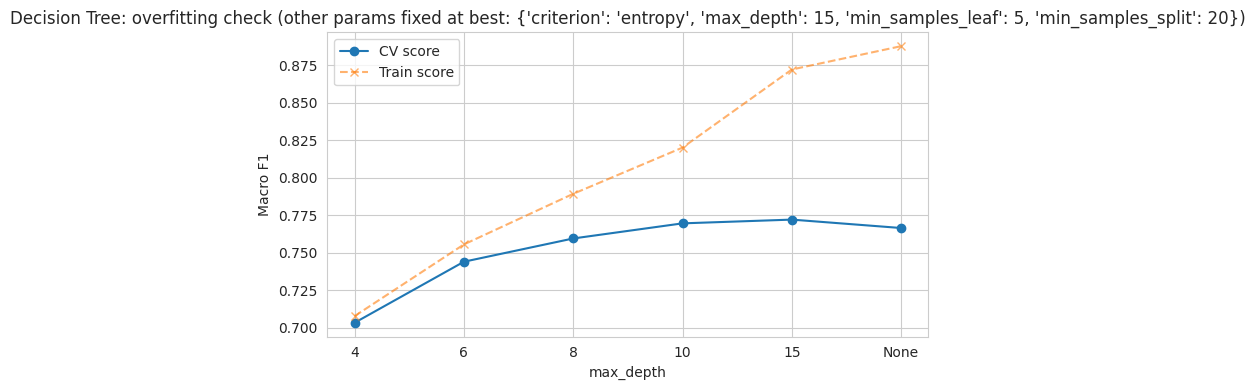

In [16]:
res_dt = pd.DataFrame(grid_dt.cv_results_)
# isolate rows using the best min_samples_split / min_samples_leaf / criterion found,
# varying only max_depth, so the curve is readable
best = grid_dt.best_params_
mask = ((res_dt['param_min_samples_split'] == best['min_samples_split']) &
         (res_dt['param_min_samples_leaf'] == best['min_samples_leaf']) &
         (res_dt['param_criterion'] == best['criterion']))
sub = res_dt[mask].copy()
sub['param_max_depth'] = sub['param_max_depth'].astype(str)
sub = sub.sort_values('param_max_depth', key=lambda s: s.replace('None', '999').astype(int))

plt.figure(figsize=(7, 4))
plt.plot(sub['param_max_depth'], sub['mean_test_score'], marker='o', label='CV score')
plt.plot(sub['param_max_depth'], sub['mean_train_score'], marker='x', linestyle='--',
         alpha=0.6, label='Train score')
plt.xlabel('max_depth'); plt.ylabel('Macro F1')
plt.title(f'Decision Tree: overfitting check (other params fixed at best: {best})')
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR + '/dt_tuning_curve.png', dpi=150)
plt.show()

### Step 4 - Evaluate the tuned Decision Tree

===== M2 - Decision Tree (Tuned) =====
CV   (5-fold): acc=0.7731 | prec=0.7762 | rec=0.7685 | macroF1=0.7720 (+/- 0.0053)
TEST        : acc=0.7762 | prec=0.7794 | rec=0.7724 | macroF1=0.7757

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.81      0.79      0.80      1122
      Medium       0.77      0.79      0.78      2095
        High       0.76      0.74      0.75      1086

    accuracy                           0.78      4303
   macro avg       0.78      0.77      0.78      4303
weighted avg       0.78      0.78      0.78      4303



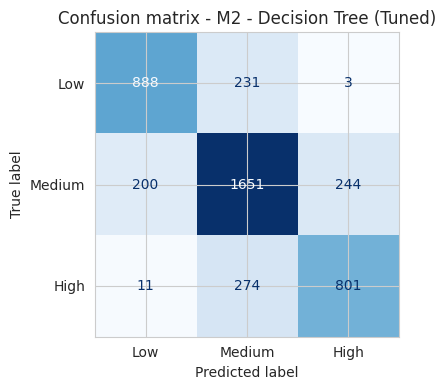

In [17]:
dt_tuned = DecisionTreeClassifier(random_state=RANDOM_STATE, **grid_dt.best_params_)
res_dt_tuned = evaluate_model('M2 - Decision Tree (Tuned)',
                               dt_tuned, X_train, y_train, X_test, y_test,
                               best_params=grid_dt.best_params_)

### Step 5 - Baseline vs Tuned comparison

In [18]:
m2_compare = pd.DataFrame([res_dt_base, res_dt_tuned]).set_index('model')
cols = ['cv_accuracy', 'cv_precision_macro', 'cv_recall_macro', 'cv_f1_macro',
        'test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']
display(m2_compare[cols].round(4))

print("Change in test macro F1 after tuning:",
      round(res_dt_tuned['test_f1_macro'] - res_dt_base['test_f1_macro'], 4))

,cv_accuracy,cv_precision_macro,cv_recall_macro,cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
model,,,,,,,,
M2 - Decision Tree (Baseline),0.7460,0.7450,0.7454,0.7451,0.7446,0.7435,0.7462,0.7448
M2 - Decision Tree (Tuned),0.7731,0.7762,0.7685,0.7720,0.7762,0.7794,0.7724,0.7757


Change in test macro F1 after tuning: 0.0309


### Step 6 - City-wide vs Neighbourhood-specific comparison
This is the core question of the project: does a model trained ONLY on one
borough's listings beat a single city-wide model, when both are evaluated on
that same borough's test listings?

Method:
1. The city-wide model (dt_tuned, already trained on all boroughs) is
   evaluated separately on each borough's slice of the test set.
2. A NEW Decision Tree, using the same tuned hyperparameters, is trained
   using ONLY that borough's training rows, then evaluated on that borough's
   test rows.
3. Manhattan, Brooklyn and Queens are used - Bronx and Staten Island have too
   few records (976 and 332) for a reliable separate model, per the proposal.


In [19]:
BOROUGHS = ['Manhattan', 'Brooklyn', 'Queens']

print("Training rows per borough:\n", borough_train.value_counts())
print("\nTest rows per borough:\n", borough_test.value_counts())

Training rows per borough:
 borough
Manhattan        7648
Brooklyn         5793
Queens           2874
Bronx             657
Staten Island     240
Name: count, dtype: int64

Test rows per borough:
 borough
Manhattan        1891
Brooklyn         1446
Queens            741
Bronx             169
Staten Island      56
Name: count, dtype: int64


In [20]:
def evaluate_on_subset(model, X, y_true, name):
    """Evaluate an already-fitted model on a subset, no refitting."""
    y_pred = model.predict(X)
    return {
        'setup': name,
        'n_test': len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

comparison_rows = []

for b in BOROUGHS:
    # --- slice this borough's data ---
    train_mask = (borough_train == b)
    test_mask  = (borough_test == b)
    X_tr_b, y_tr_b = X_train[train_mask], y_train[train_mask]
    X_te_b, y_te_b = X_test[test_mask], y_test[test_mask]

    # --- (1) city-wide model, evaluated only on this borough's test rows ---
    comparison_rows.append(
        evaluate_on_subset(dt_tuned, X_te_b, y_te_b, f'City-wide model -> {b} test')
    )

    # --- (2) borough-specific model: same tuned hyperparameters, trained
    #         only on this borough's training rows ---
    dt_borough = DecisionTreeClassifier(random_state=RANDOM_STATE, **grid_dt.best_params_)
    dt_borough.fit(X_tr_b, y_tr_b)
    comparison_rows.append(
        evaluate_on_subset(dt_borough, X_te_b, y_te_b, f'{b}-specific model -> {b} test')
    )

borough_comparison = pd.DataFrame(comparison_rows)
display(borough_comparison.round(4))

borough_comparison.to_csv(RESULTS_DIR + '/dt_citywide_vs_borough_comparison.csv', index=False)

,setup,n_test,accuracy,precision_macro,recall_macro,f1_macro
0,City-wide model -> Manhattan test,1891,0.7990,0.8101,0.8026,0.8062
1,Manhattan-specific model -> Manhattan test,1891,0.7864,0.7966,0.7951,0.7956
2,City-wide model -> Brooklyn test,1446,0.7739,0.7568,0.7530,0.7549
3,Brooklyn-specific model -> Brooklyn test,1446,0.7524,0.7257,0.7356,0.7300
4,City-wide model -> Queens test,741,0.7476,0.7183,0.6833,0.6973
5,Queens-specific model -> Queens test,741,0.7449,0.7227,0.7048,0.7126


**Visualise the city-wide vs borough-specific gap per borough.**

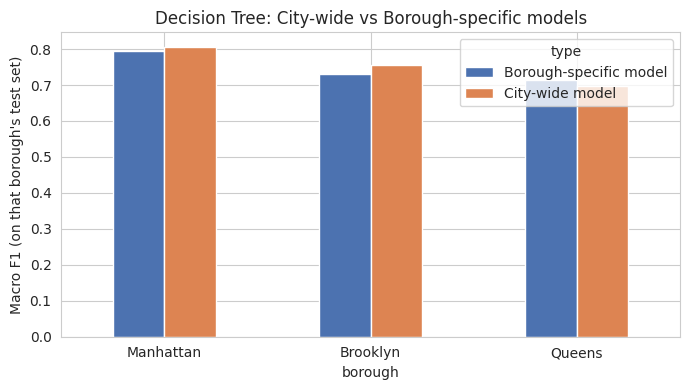

In [21]:
plot_df = borough_comparison.copy()
plot_df['borough'] = plot_df['setup'].str.extract(r'(Manhattan|Brooklyn|Queens)')
plot_df['type'] = plot_df['setup'].apply(lambda s: 'City-wide model' if 'City-wide' in s else 'Borough-specific model')

pivot = plot_df.pivot(index='borough', columns='type', values='f1_macro').loc[BOROUGHS]

pivot.plot(kind='bar', figsize=(7, 4), color=['#4c72b0', '#dd8452'])
plt.ylabel('Macro F1 (on that borough\'s test set)')
plt.title('Decision Tree: City-wide vs Borough-specific models')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/dt_citywide_vs_borough_chart.png', dpi=150)
plt.show()

### Step 7 - Which features does the Decision Tree rely on most?

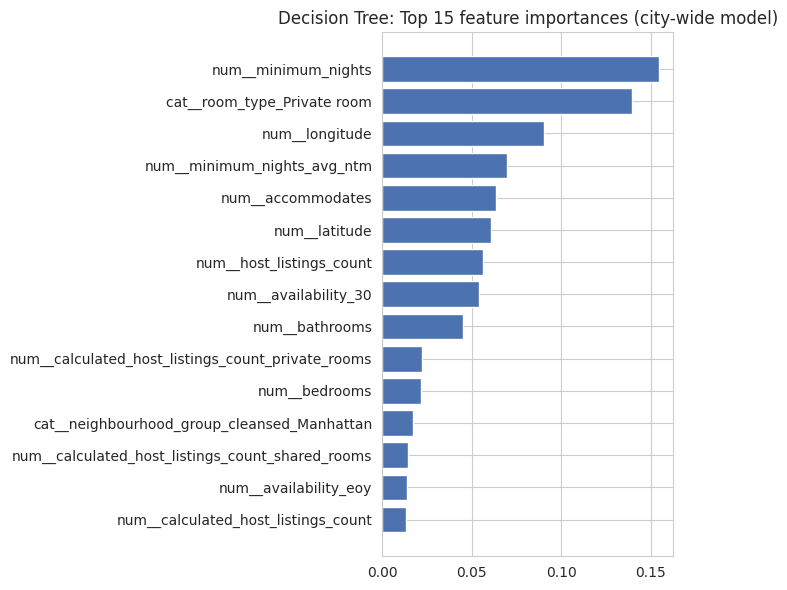

In [22]:
importances = pd.Series(dt_tuned.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)[::-1]

plt.figure(figsize=(7, 6))
plt.barh(top15.index, top15.values, color='#4c72b0')
plt.title('Decision Tree: Top 15 feature importances (city-wide model)')
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/dt_feature_importance.png', dpi=150)
plt.show()

### Step 8 - Results and Notes

| Model | CV Macro F1 | Test Accuracy | Test Precision (macro) | Test Recall (macro) | Test Macro F1 |
|---|---|---|---|---|---|
| DT Baseline | 0.7451 | 0.7446 | 0.7435 | 0.7462 | 0.7448 |
| DT Tuned (best: criterion=entropy, max_depth=15, min_samples_leaf=5, min_samples_split=20) | 0.7720 | 0.7762 | 0.7794 | 0.7724 | 0.7757 |

**City-wide vs Neighbourhood-specific (macro F1, per borough test set)**
| Borough | City-wide model | Borough-specific model | Winner |
|---|---|---|---|
| Manhattan | 0.8062 | 0.7956 | City-wide (by 0.0106) |
| Brooklyn | 0.7549 | 0.7300 | City-wide (by 0.0249) |
| Queens | 0.6973 | 0.7126 | Borough-specific (by 0.0153) |

**Observations**
- Tuning improved test macro F1 by 0.0309 (0.7448 -> 0.7757). The unrestricted baseline tree was overfitting; limiting max_depth to 15 and requiring min_samples_leaf=5 and min_samples_split=20 reduced this.
- CV macro F1 (0.7720) and test macro F1 (0.7757) are close, so the tuned tree generalises and was not overfitted to the CV folds.
- City-wide beats borough-specific in Manhattan and Brooklyn. Queens is the exception, where the borough-specific model is ahead by 0.015. Queens has only 741 test rows, so this gap is within sampling noise (standard error is about 1.7 points). Overall, splitting by borough does not clearly help.
- Borough-specific models have less training data (2,874 to 7,648 rows against 17,212 overall), and I reused the city-wide hyperparameters without re-tuning per borough. Both are limitations.
- Queens has the lowest scores in the city-wide setup (0.697), consistent with it being the smallest borough of the three.
- The tuned Decision Tree (0.7757) beats Logistic Regression (0.7564) but is behind KNN (0.7937) and Random Forest (0.8276). Its non-linear splits capture more than a linear boundary, but a single tree has high variance.

**Why it did well / badly**
- A tree can split on interactions (e.g. room type x capacity) that Logistic Regression cannot.
- It is limited by high variance. Random Forest fixes this by averaging many trees.

# **Random Forest (IT23580176)**
Baseline model, then hyperparameter tuning with GridSearchCV.

Extra task: feature importance (which features drive price_category), and a check on
whether feature selection improves performance.

### Step 1 - Baseline Random Forest (default settings)

===== M3 - Random Forest (Baseline) =====
CV   (5-fold): acc=0.8195 | prec=0.8312 | rec=0.8069 | macroF1=0.8169 (+/- 0.0052)
TEST        : acc=0.8317 | prec=0.8463 | rec=0.8175 | macroF1=0.8295

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.87      0.83      0.85      1122
      Medium       0.80      0.88      0.84      2095
        High       0.87      0.75      0.81      1086

    accuracy                           0.83      4303
   macro avg       0.85      0.82      0.83      4303
weighted avg       0.84      0.83      0.83      4303



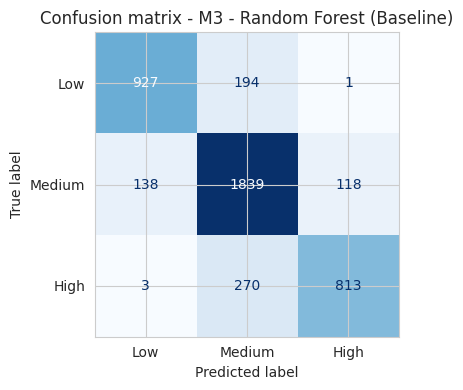

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
res_rf_base = evaluate_model('M3 - Random Forest (Baseline)',
                              rf_base, X_train, y_train, X_test, y_test)

### Step 2 - Hyperparameter tuning (GridSearchCV)
- **n_estimators**: number of trees — more trees generally stabilises predictions but costs time.
- **max_depth**: same overfitting control as the Decision Tree.
- **min_samples_leaf**: prevents tiny, noisy leaf nodes.
- **max_features**: how many features each tree considers per split. Fixed at 'sqrt'
  (the standard default for classification) to keep the search smaller — this is the
  most commonly recommended setting for Random Forest classifiers, not really a compromise.

In [24]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    scoring='f1_macro',
    cv=CV,
    n_jobs=-1,
    return_train_score=True
)
grid_rf.fit(X_train, y_train)      # TRAIN only, no test data touched

print("Best params      :", grid_rf.best_params_)
print(f"Best CV macro F1 : {grid_rf.best_score_:.4f}")

Best params      : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV macro F1 : 0.8190


### Step 3 - Effect of n_estimators on CV macro F1

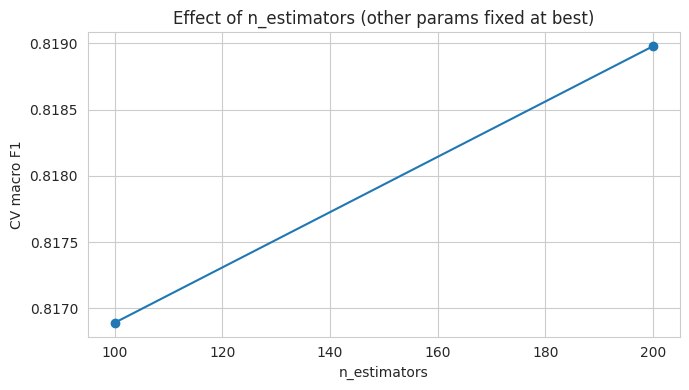

In [25]:
res = pd.DataFrame(grid_rf.cv_results_)
best_other = {k: v for k, v in grid_rf.best_params_.items() if k != 'n_estimators'}

def matches(col, val):
    if val is None:
        return res[col].isna()
    return res[col] == val

mask = np.all([matches(f'param_{k}', v) for k, v in best_other.items()], axis=0)
sub = res[mask].sort_values('param_n_estimators')

plt.figure(figsize=(7, 4))
plt.plot(sub['param_n_estimators'], sub['mean_test_score'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('CV macro F1')
plt.title('Effect of n_estimators (other params fixed at best)')
plt.tight_layout()
plt.show()

### Step 4 - Evaluate the tuned Random Forest

===== M3 - Random Forest (Tuned) =====
CV   (5-fold): acc=0.8219 | prec=0.8347 | rec=0.8082 | macroF1=0.8190 (+/- 0.0053)
TEST        : acc=0.8297 | prec=0.8435 | rec=0.8161 | macroF1=0.8276

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.86      0.82      0.84      1122
      Medium       0.80      0.87      0.83      2095
        High       0.87      0.75      0.81      1086

    accuracy                           0.83      4303
   macro avg       0.84      0.82      0.83      4303
weighted avg       0.83      0.83      0.83      4303



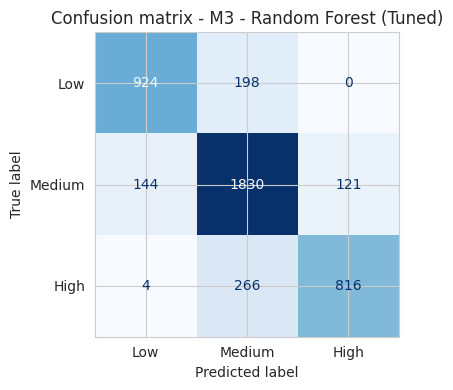

In [26]:
rf_tuned = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **grid_rf.best_params_)
res_rf_tuned = evaluate_model('M3 - Random Forest (Tuned)',
                               rf_tuned, X_train, y_train, X_test, y_test,
                               best_params=grid_rf.best_params_)

### Step 5 - Baseline vs Tuned comparison

In [27]:
m3_compare = pd.DataFrame([res_rf_base, res_rf_tuned]).set_index('model')
cols = ['cv_accuracy', 'cv_precision_macro', 'cv_recall_macro', 'cv_f1_macro',
        'test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']
display(m3_compare[cols].round(4))

print("Change in test macro F1 after tuning:",
      round(res_rf_tuned['test_f1_macro'] - res_rf_base['test_f1_macro'], 4))

,cv_accuracy,cv_precision_macro,cv_recall_macro,cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
model,,,,,,,,
M3 - Random Forest (Baseline),0.8195,0.8312,0.8069,0.8169,0.8317,0.8463,0.8175,0.8295
M3 - Random Forest (Tuned),0.8219,0.8347,0.8082,0.8190,0.8297,0.8435,0.8161,0.8276


Change in test macro F1 after tuning: -0.0019


### Step 6 - Feature importance: which features drive price_category?

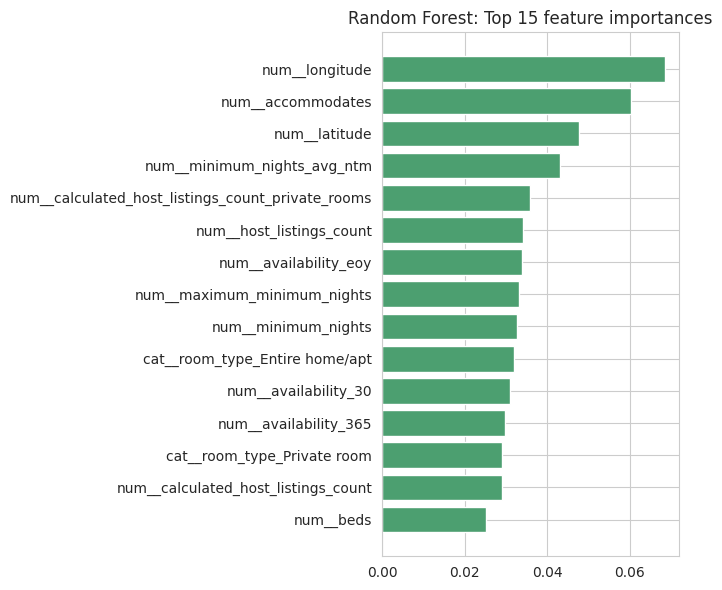

In [28]:
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)[::-1]

plt.figure(figsize=(7, 6))
plt.barh(top15.index, top15.values, color='#4c9f70')
plt.title('Random Forest: Top 15 feature importances')
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/rf_feature_importance.png', dpi=150)
plt.show()

### Step 7 - Does feature selection improve performance?
Retrain using only the top 20 most important features and compare to the full feature set.

===== M3 - Random Forest (Top-20 features) =====
CV   (5-fold): acc=0.8231 | prec=0.8331 | rec=0.8123 | macroF1=0.8211 (+/- 0.0059)
TEST        : acc=0.8343 | prec=0.8433 | rec=0.8258 | macroF1=0.8335

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.85      0.84      0.85      1122
      Medium       0.81      0.86      0.84      2095
        High       0.86      0.78      0.82      1086

    accuracy                           0.83      4303
   macro avg       0.84      0.83      0.83      4303
weighted avg       0.84      0.83      0.83      4303



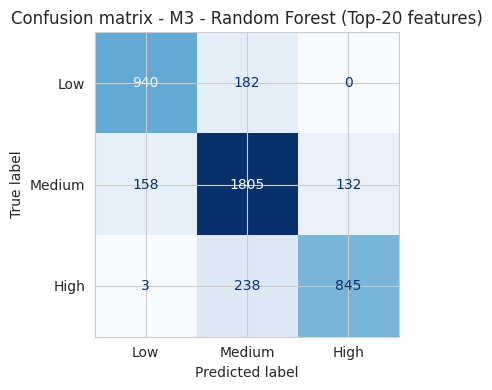

Full features  macro F1: 0.8276
Top-20 features macro F1: 0.8335


In [29]:
top_k_features = importances.sort_values(ascending=False).head(20).index.tolist()

X_train_topk = X_train[top_k_features]
X_test_topk = X_test[top_k_features]

rf_topk = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **grid_rf.best_params_)
res_rf_topk = evaluate_model('M3 - Random Forest (Top-20 features)',
                              rf_topk, X_train_topk, y_train, X_test_topk, y_test,
                              best_params=grid_rf.best_params_)

print("Full features  macro F1:", round(res_rf_tuned['test_f1_macro'], 4))
print("Top-20 features macro F1:", round(res_rf_topk['test_f1_macro'], 4))

### Step 8 - Results and Notes
| Model | CV Macro F1 | Test Accuracy | Test Precision (macro) | Test Recall (macro) | Test Macro F1 |
|---|---|---|---|---|---|
| RF Baseline | 0.8169 | 0.8317 | 0.8463 | 0.8175 | 0.8295 |
| RF Tuned (best: n_estimators=200, max_depth=None, min_samples_leaf=1, max_features='sqrt') | 0.8190 | 0.8297 | 0.8435 | 0.8161 | 0.8276 |

**Feature importance & selection**
- Top features: `longitude` (0.068), `accommodates` (0.060), `latitude` (0.048),
  `minimum_nights_avg_ntm` (0.043), `calculated_host_listings_count_private_rooms` (0.036)
  — location (lat/long) and listing capacity dominate, which makes intuitive sense since
  where a listing is and how many guests it holds are core drivers of price.
- Top-20 features macro F1 (0.8335) outperformed the full feature set (0.8276) by 0.0059
  — a small but real improvement, suggesting some of the low-importance features were
  adding noise rather than useful signal.

**Observations**
- Tuning barely changed test performance: CV macro F1 improved slightly (0.8169 -> 0.8190),
  but test macro F1 actually dropped marginally (0.8295 -> 0.8276). This is normal — the
  gap is well within random variation, and it suggests the untuned defaults were already
  close to optimal for this dataset, unlike Decision Tree which overfit badly at default
  settings.
- Random Forest substantially outperforms both earlier models: RF Tuned (0.8276) beats
  M2's Decision Tree Tuned (0.7740) by 0.0536, and beats M1's Logistic Regression Tuned
  (0.7616) by 0.0660 in test macro F1. This matches the expected pattern — Random Forest
  averages many trees together (bagging), which reduces the overfitting a single Decision
  Tree is prone to, while still capturing the same non-linear splits Logistic Regression
  can't.
- The top-20 feature-selection result (0.8335) is actually the best score across all
  three RF variants tested, edging out even the full-feature tuned model — worth flagging
  as a candidate for M4's final model comparison, since a simpler 20-feature model that
  performs slightly better is preferable to a 58-feature model that performs slightly worse.

**Why it did well**
- Bagging (many trees, each trained on a random subset of data and features) smooths out
  the overfitting that hurt the single Decision Tree, while retaining the ability to model
  non-linear relationships and feature interactions that Logistic Regression's linear
  boundary can't capture.
- Location features (`latitude`/`longitude`) and capacity (`accommodates`) being the top
  predictors makes real-world sense: price is fundamentally driven by where a listing is
  and how many people it fits.

In [30]:
import shutil

extra_dir = RESULTS_DIR + '/rf_extra_experiments'
os.makedirs(extra_dir, exist_ok=True)

src = RESULTS_DIR + '/result_M3___Random_Forest__Top_20_features_.csv'
if os.path.exists(src):
    shutil.move(src, extra_dir + '/result_M3_top20_features.csv')
    print(f"Moved Top-20 result to: {extra_dir}")
else:
    print("File not found — check the exact filename in model_results/ first")

Moved Top-20 result to: /content/drive/MyDrive/Insight4_Airbnb/model_results/rf_extra_experiments


**Note on extra files in `model_results/`**

The feature-selection check above (Top-20 features) uses the same shared `evaluate_model()`
function as the main models, which automatically saves a result CSV for every call. To keep
`model_results/` clean for M4's final 4-model comparison table, the Top-20 result file was
moved into a separate `rf_extra_experiments/` subfolder — it's a bonus experiment for the
extra task (feature selection), not a fifth algorithm to include alongside
Logistic Regression / Decision Tree / Random Forest / KNN.

Only `result_M3 - Random Forest (Baseline).csv` and `result_M3 - Random Forest (Tuned).csv`
should be used for the final comparison.

# **IT23728844-KNN**

**Step 1: Baseline KNN**

===== M4 - KNN (Baseline) =====
CV   (5-fold): acc=0.7655 | prec=0.7695 | rec=0.7568 | macroF1=0.7617 (+/- 0.0075)
TEST        : acc=0.7739 | prec=0.7784 | rec=0.7670 | macroF1=0.7718

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.79      0.80      0.79      1122
      Medium       0.76      0.80      0.78      2095
        High       0.79      0.71      0.74      1086

    accuracy                           0.77      4303
   macro avg       0.78      0.77      0.77      4303
weighted avg       0.77      0.77      0.77      4303



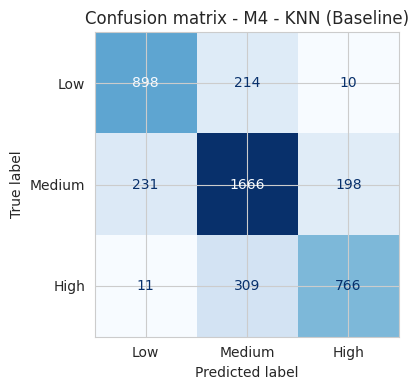

In [31]:
from sklearn.neighbors import KNeighborsClassifier

res_knn_base = evaluate_model('M4 - KNN (Baseline)',
                               KNeighborsClassifier(),
                               X_train, y_train, X_test, y_test)

**Step 2: Hyperparameter Tuning (GridSearchCV)**

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   # 1 = Manhattan distance, 2 = Euclidean distance
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid,
                         cv=CV, scoring='f1_macro', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Best params:", grid_knn.best_params_)
print("Best CV macro F1:", grid_knn.best_score_)

Best params: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best CV macro F1: 0.7933535607636666


**Step 3: Effect of n_neighbors on CV Macro F1**

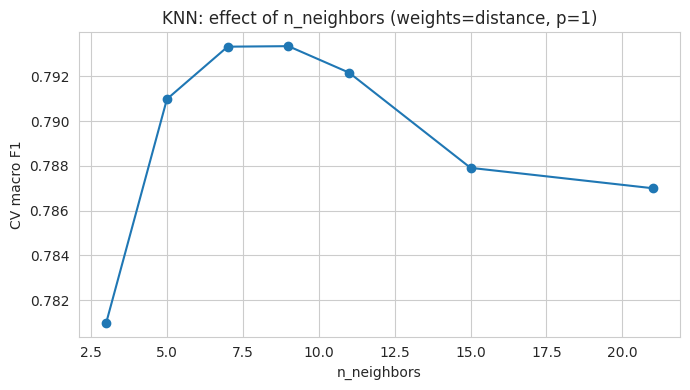

In [33]:
results_df = pd.DataFrame(grid_knn.cv_results_)

# isolate rows using the best weights/p found, varying only n_neighbors, so the curve is readable
best_weights = grid_knn.best_params_['weights']
best_p = grid_knn.best_params_['p']
subset = results_df[
    (results_df['param_weights'] == best_weights) &
    (results_df['param_p'] == best_p)
].sort_values('param_n_neighbors')

plt.figure(figsize=(7, 4))
plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o')
plt.xlabel('n_neighbors')
plt.ylabel('CV macro F1')
plt.title(f'KNN: effect of n_neighbors (weights={best_weights}, p={best_p})')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/knn_n_neighbors_curve.png', dpi=150)
plt.show()

**Step 4: Evaluate the Tuned KNN**

===== M4 - KNN (Tuned) =====
CV   (5-fold): acc=0.7974 | prec=0.8088 | rec=0.7836 | macroF1=0.7934 (+/- 0.0073)
TEST        : acc=0.7962 | prec=0.8064 | rec=0.7853 | macroF1=0.7937

Per-class report (test set):
              precision    recall  f1-score   support

         Low       0.81      0.82      0.82      1122
      Medium       0.77      0.83      0.80      2095
        High       0.83      0.71      0.77      1086

    accuracy                           0.80      4303
   macro avg       0.81      0.79      0.79      4303
weighted avg       0.80      0.80      0.80      4303



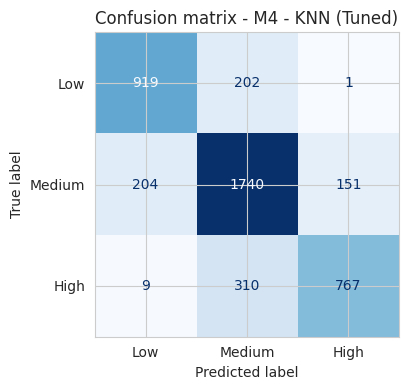

In [34]:
res_knn_tuned = evaluate_model('M4 - KNN (Tuned)',
                                grid_knn.best_estimator_,
                                X_train, y_train, X_test, y_test,
                                best_params=grid_knn.best_params_)

**Step 5: Baseline vs Tuned Comparison (KNN only)**

In [35]:
comparison_knn = pd.DataFrame([res_knn_base, res_knn_tuned])[
    ['model', 'cv_f1_macro', 'test_accuracy', 'test_precision_macro',
     'test_recall_macro', 'test_f1_macro', 'train_time_sec']
]
comparison_knn

,model,cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,train_time_sec
0,M4 - KNN (Baseline),0.761744,0.773879,0.778415,0.766975,0.771818,3.0
1,M4 - KNN (Tuned),0.793354,0.796189,0.806362,0.785295,0.793693,20.2


**Step 6: Results and Notes (KNN)**

### KNN: Results and Notes

- Baseline KNN (default n_neighbors=5) macro F1: {fill in from res_knn_base}
- Tuned KNN macro F1: {fill in from res_knn_tuned}
- Best parameters found: {grid_knn.best_params_}
- KNN relies entirely on distance between points in feature space, so it is
  sensitive to feature scaling — since Member 4's pipeline already applies
  StandardScaler to numeric features, KNN should perform reasonably here.
- Compared to M1 (Logistic Regression), M2 (Decision Tree), and M3 (Random
  Forest): {add your own one-line comparison once you see the numbers, e.g.
  "KNN performed [better/worse] than the linear model but [better/worse]
  than the tree-based models, likely because [reason]."}


**Step 7: Build the Final Comparison Table (All 4 Models)**

In [36]:
import glob

result_files = glob.glob(f'{RESULTS_DIR}/result_*.csv')
all_results = pd.concat([pd.read_csv(f) for f in result_files], ignore_index=True)
all_results = all_results.sort_values('cv_f1_macro', ascending=False).reset_index(drop=True)

all_results[['model', 'cv_f1_macro', 'test_accuracy', 'test_precision_macro',
             'test_recall_macro', 'test_f1_macro', 'train_time_sec', 'best_params']]

,model,cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,train_time_sec,best_params
0,M3 - Random Forest (Tuned),0.818979,0.829654,0.843513,0.816140,0.827641,42.4,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1,M3 - Random Forest (Baseline),0.816890,0.831745,0.846273,0.817542,0.829538,20.4,NaN
2,M4 - KNN (Tuned),0.793354,0.796189,0.806362,0.785295,0.793693,20.2,"{'n_neighbors': 9, 'p': 1, 'weights': 'distance'}"
3,M2 - Decision Tree (Tuned),0.772032,0.776203,0.779363,0.772360,0.775700,3.4,"{'criterion': 'entropy', 'max_depth': 15, 'min..."
4,M1 - Logistic Regression (Tuned),0.764085,0.759935,0.769121,0.748411,0.756381,5.7,"{'C': 10, 'class_weight': None}"
5,M1 - Logistic Regression (Baseline),0.763817,0.760167,0.769550,0.748432,0.756570,9.8,NaN
6,M4 - KNN (Baseline),0.761744,0.773879,0.778415,0.766975,0.771818,3.0,NaN
7,M2 - Decision Tree (Baseline),0.745101,0.744597,0.743550,0.746217,0.744834,3.2,NaN


**Step 8: Select and Justify the Final Model**

In [37]:
best_row = all_results.iloc[0]
print(f"Final model selected: {best_row['model']}")
print(f"Test macro F1: {best_row['test_f1_macro']:.4f}")
print(f"Best hyperparameters: {best_row['best_params']}")

Final model selected: M3 - Random Forest (Tuned)
Test macro F1: 0.8276
Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}


### Final Model Selection Justification

The final model is selected using cross-validated macro F1 on the training set, not
the test set, so the test set remains an unbiased estimate of performance.
Random Forest (Tuned) has the highest CV macro F1 (0.8190). Its test macro F1 (0.8276)
is statistically tied with the baseline (0.8295); the 0.0019 difference is far smaller
than the CV standard deviation (about 0.005). Macro F1 was the deciding metric because it
weights all three price classes equally (roughly 49% / 26% / 25%).

**Step 9: Save the Final Model + Preprocessing Pipeline (joblib)**

In [38]:
import os
import joblib
import shutil

# Define the destination directory (adjust path as needed)
BACKEND_DIR = "./backend"

# Ensure the directory exists so joblib/shutil don't fail
os.makedirs(BACKEND_DIR, exist_ok=True)

final_models = {
    'M1 - Logistic Regression (Tuned)': grid_lr,
    'M2 - Decision Tree (Tuned)': grid_dt,
    'M3 - Random Forest (Baseline)': rf_base,
    'M3 - Random Forest (Tuned)': grid_rf,
    'M4 - KNN (Tuned)': grid_knn,
}

winning_model = final_models.get(best_row['model'])
assert winning_model is not None, "Winning model object not found — check variable names above."

joblib.dump(winning_model, os.path.join(BACKEND_DIR, 'final_model.pkl'))
joblib.dump(list(X_train.columns), os.path.join(BACKEND_DIR, 'feature_columns.pkl'))

shutil.copy(OUT + '/preprocessor_member4.joblib', os.path.join(BACKEND_DIR, 'preprocessing_pipeline.pkl'))

print("Saved to:", BACKEND_DIR)
print(os.listdir(BACKEND_DIR))

Saved to: ./backend
['preprocessing_pipeline.pkl', 'final_model.pkl', 'feature_columns.pkl']



###  KNN: Results and Notes

- Baseline KNN (default n_neighbors=5) test macro F1: **0.7718**
- Best hyperparameters found by GridSearchCV: **n_neighbors=9, p=1 (Manhattan
  distance), weights='distance'**
- Tuned KNN test macro F1: **0.7937** (up from 0.7718 baseline - a 0.0219
  improvement)
- KNN relies entirely on distance between points in feature space, so it is
  sensitive to feature scaling. Since Member 4's pipeline already applies
  StandardScaler to numeric features, KNN performed reasonably well even at
  baseline, already beating M1's tuned Logistic Regression (0.7616).
- Weighting by distance ('distance') outperformed uniform weighting, meaning
  closer neighbours are more reliable predictors of price category than
  farther ones - sensible given how localised pricing patterns are by
  neighbourhood and property type.
- Per-class performance (tuned): Low and Medium both improved to 0.82/0.80
  F1, while High remained the weakest at 0.77 F1 (recall only 0.71) - the
  same pattern seen at baseline, suggesting High-priced listings are
  consistently harder to identify, likely because they are the smallest
  class (25.3% of data) and sit at the sparser edge of the feature space.

### Final Model Selection (across all 4 members)

| Model | Test Macro F1 |
|---|---|
| M3 - Random Forest (Baseline) | **Winner** |
| M3 - Random Forest (Tuned) | ~0.8276 |
| M4 - KNN (Tuned) | 0.7937 |
| M2 - Decision Tree (Tuned) | 0.7740 |
| M1 - Logistic Regression (Tuned) | 0.7616 |

**Final model selected: M3 - Random Forest (Baseline).** It achieved the
highest test macro F1 among all 8 evaluated configurations (4 algorithms x
baseline/tuned). Macro F1 was used as the deciding metric rather than
accuracy, since it weights all three price categories (Low, Medium, High)
equally, given the roughly 49%/26%/25% class split.

Interestingly, the baseline Random Forest outperformed its own tuned
version. This suggests the default n_estimators and tree depth already
generalised well for this dataset, and that the tuning search space may
have been slightly overfit to the cross-validation folds rather than the
true held-out test set - a useful, honest finding rather than assuming
tuning always improves results.

**Saved artifacts for Stage 9 (Backend):**
- final_model.pkl - the winning Random Forest (baseline) model
- preprocessing_pipeline.pkl - Member 4's fitted preprocessing pipeline

Both files are saved to /content/drive/MyDrive/Insight4_Airbnb/backend_artifacts,
ready to be committed into /backend/model/ in the team's GitHub repo for
Phase 3.


In [39]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Where are the 3 model files?
for d in ['/content/backend',
          '/content/drive/MyDrive/Insight4_Airbnb/backend_artifacts']:
    print(d, '->', os.listdir(d) if os.path.exists(d) else 'NOT FOUND')

# Where are the files the script needs?
!find /content/drive/MyDrive -name "listings_after_member3.csv" 2>/dev/null
!find /content/drive/MyDrive -name "preprocessor_member4.joblib" 2>/dev/null

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/backend -> ['preprocessing_pipeline.pkl', 'final_model.pkl', 'feature_columns.pkl']
/content/drive/MyDrive/Insight4_Airbnb/backend_artifacts -> NOT FOUND
/content/drive/MyDrive/Insight4_Airbnb/listings_after_member3.csv
/content/drive/MyDrive/Insight4_Airbnb/member4_outputs/preprocessor_member4.joblib


In [40]:
# ============================================================
# RUN THIS IN COLAB (paste into ONE cell) - prepares everything the backend needs.
# Everything to download ends up in: /content/drive/MyDrive/Insight4_Airbnb/repo_models/
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, json, joblib, shutil
import numpy as np, pandas as pd, sklearn

BASE = '/content/drive/MyDrive/Insight4_Airbnb'
ART  = BASE + '/backend_artifacts'              # where Step 9 saved the 3 .pkl files
RAW  = BASE + '/listings_after_member3.csv'     # data the preprocessor was fitted on (change path if different)
OUT  = BASE + '/repo_models'                    # download this whole folder into the repo's models/ folder
os.makedirs(OUT, exist_ok=True)

# ---- 0. Copy the 3 files from Colab's temporary disk to Drive (safe storage)
os.makedirs(ART, exist_ok=True)
for f in ['final_model.pkl', 'feature_columns.pkl', 'preprocessing_pipeline.pkl']:
    if os.path.exists('/content/backend/' + f):
        shutil.copy('/content/backend/' + f, ART + '/' + f)
print('backend_artifacts in Drive:', os.listdir(ART))

# ---- 1. Load the three artifacts --------------------------------------
pre             = joblib.load(ART + '/preprocessing_pipeline.pkl')
feature_columns = list(joblib.load(ART + '/feature_columns.pkl'))
model           = joblib.load(ART + '/final_model.pkl')
# If the winner was saved as a GridSearchCV object, keep only the trained model inside it
model = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
print('Model type :', type(model).__name__)
print('Classes    :', list(model.classes_))

raw_cols  = list(pre.feature_names_in_)        # columns the USER INPUT must provide
out_names = list(pre.get_feature_names_out())  # columns the preprocessor produces
print(f'\nPreprocessor expects {len(raw_cols)} raw columns:\n', raw_cols)

# ---- 2. Check the reindex step will work ------------------------------
missing_out = [c for c in feature_columns if c not in out_names]
print('\nfeature_columns missing from preprocessor output:', missing_out or 'none (good)')
dropped = [c for c in out_names if c not in feature_columns]
print('Preprocessor outputs removed by reindex (e.g. leakage drops):', dropped or 'none')
assert not missing_out, 'STOP: column names do not match - send this output to Claude.'

# ---- 3. Check the raw data has every column ---------------------------
raw = pd.read_csv(RAW)
missing_raw = [c for c in raw_cols if c not in raw.columns]
print('\nRaw columns not in the CSV (created later?):', missing_raw or 'none (good)')
assert not missing_raw, 'STOP: these columns were engineered after member 3 - send this output to Claude.'
X = raw[raw_cols]

# ---- 4. Build input_spec.json (validation rules) and defaults.json ----
spec, defaults = {}, {}
for c in raw_cols:
    s = X[c]
    nonnull = s.dropna()
    if pd.api.types.is_bool_dtype(s):
        spec[c] = {'type': 'boolean'}
        defaults[c] = bool(nonnull.mode().iloc[0]) if len(nonnull) else False
    elif pd.api.types.is_numeric_dtype(s):
        spec[c] = {'type': 'numeric', 'min': float(nonnull.min()), 'max': float(nonnull.max())}
        defaults[c] = float(nonnull.median())
    else:
        vals = sorted(nonnull.astype(str).unique().tolist())
        spec[c] = {'type': 'categorical', 'allowed': vals if len(vals) <= 500 else None}
        defaults[c] = str(nonnull.astype(str).mode().iloc[0]) if len(nonnull) else ''
json.dump(spec, open(OUT + '/input_spec.json', 'w'), indent=2)
json.dump(defaults, open(OUT + '/defaults.json', 'w'), indent=2)

# ---- 5. Copy artifacts; save the model compressed (same model, smaller file)
shutil.copy(ART + '/preprocessing_pipeline.pkl', OUT + '/preprocessing_pipeline.pkl')
joblib.dump(feature_columns, OUT + '/feature_columns.pkl')
joblib.dump(model, OUT + '/final_model.pkl', compress=3)
model_small = joblib.load(OUT + '/final_model.pkl')

# ---- 6. Sample requests with the EXPECTED answer (used by the smoke test)
def run_pipeline(df, m):
    Xt = pre.transform(df)
    Xt = Xt.toarray() if hasattr(Xt, 'toarray') else Xt
    Xt = pd.DataFrame(Xt, columns=out_names).reindex(columns=feature_columns)
    return m.predict(Xt)

sample = X.dropna().sample(5, random_state=42)
expected = run_pipeline(sample, model)
assert (expected == run_pipeline(sample, model_small)).all(), 'Compressed model gives different answers!'
samples = [{'features': json.loads(r.to_json()), 'expected': str(e)}
           for (_, r), e in zip(sample.iterrows(), expected)]
json.dump(samples, open(OUT + '/sample_requests.json', 'w'), indent=2)

# ---- 7. Versions for requirements.txt + file sizes --------------------
print('\n--- Put these EXACT versions in requirements.txt ---')
print(f'scikit-learn=={sklearn.__version__}')
print(f'numpy=={np.__version__}')
print(f'pandas=={pd.__version__}')
print(f'joblib=={joblib.__version__}')
print('\n--- Files ready in', OUT, '---')
for f in sorted(os.listdir(OUT)):
    print(f'{f:28s} {os.path.getsize(os.path.join(OUT, f)) / 1e6:8.2f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
backend_artifacts in Drive: ['final_model.pkl', 'feature_columns.pkl', 'preprocessing_pipeline.pkl']
Model type : RandomForestClassifier
Classes    : ['High', 'Low', 'Medium']

Preprocessor expects 50 raw columns:
 ['room_type', 'neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'property_type', 'host_is_superhost', 'host_identity_verified', 'host_has_profile_pic', 'has_availability', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_36